In [1]:
import os
import time

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import importlib

import utils.data as datutils
import utils.plots as plots
import utils.file as futils
import utils.corrs as corutils

import warnings
from pandas.errors import ParserWarning

warnings.simplefilter(action='ignore', category=ParserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['axes.labelsize'] = 18
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

In [3]:
def get_ds_all():
    df_dict = {}
    for i in range(32, 129):
        dsdf = futils.get_ds(snap=i)
        dsdf['snap'] = i
        df_dict[i] = dsdf

    return df_dict


In [4]:
m14 = pd.read_csv('data/gadgetx3k/mag_diff_GadgetX_3k.csv')
m14.set_index('ID', inplace=True)

In [18]:
dsdict = get_ds_all()
for df in dsdict.values():
    df['m14'] = m14['3d'].values

In [8]:
seed = list(range(100))
percs_200 = []
percs_500 = []
for snap in dsdict.keys():
    df = dsdict[snap]
    df = df.drop(columns=['snap'])
    sample_size = len(df)
    corrs_list = [df.sample(n=sample_size, replace=True,
                            random_state=s).corr(method='spearman')
        for s in seed
    ]
    p10_200 = np.percentile(corrs_list, 10, axis=0)[2]
    p25_200 = np.percentile(corrs_list, 25, axis=0)[2]
    p50_200 = np.percentile(corrs_list, 50, axis=0)[2]
    p75_200 = np.percentile(corrs_list, 75, axis=0)[2]
    p90_200 = np.percentile(corrs_list, 90, axis=0)[2]
    percs_200.append((p10_200, p25_200, p50_200, p75_200, p90_200))

    p10_500 = np.percentile(corrs_list, 10, axis=0)[6]
    p25_500 = np.percentile(corrs_list, 25, axis=0)[6]
    p50_500 = np.percentile(corrs_list, 50, axis=0)[6]
    p75_500 = np.percentile(corrs_list, 75, axis=0)[6]
    p90_500 = np.percentile(corrs_list, 90, axis=0)[6]
    percs_500.append((p10_500, p25_500, p50_500, p75_500, p90_500))

percs_200 = np.array(percs_200)
percs_500 = np.array(percs_500)

In [9]:
redshift_list = pd.read_csv('data/gadgetx3k/redshift_list.txt', sep=r'\s+')

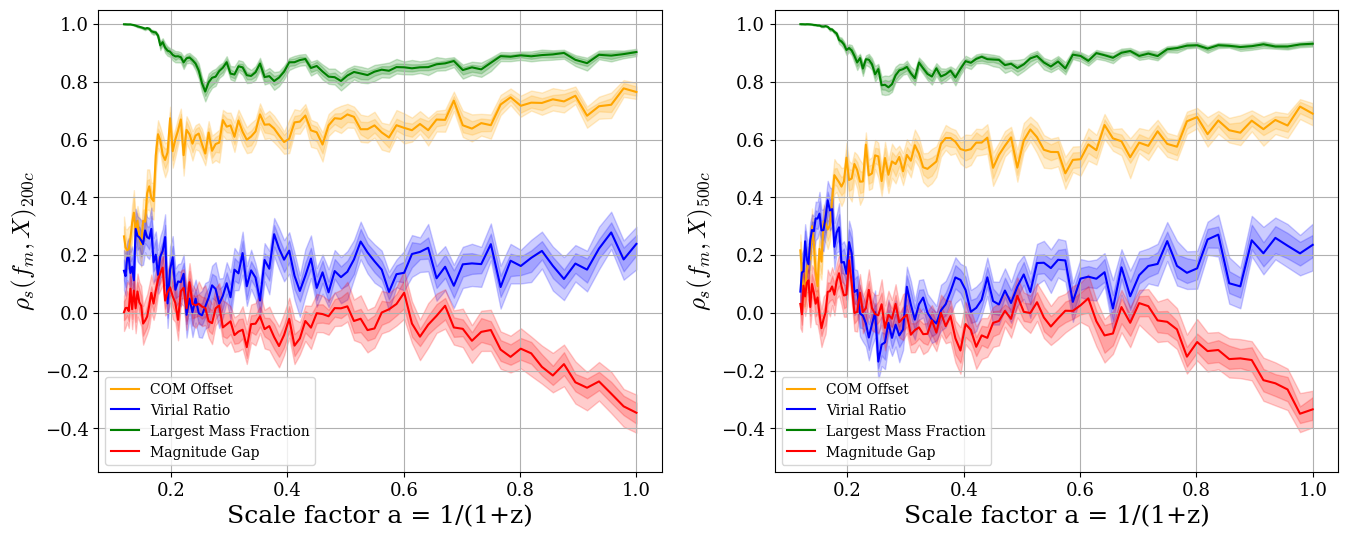

In [17]:
yticks = np.arange(-0.4, 1.2, 0.2)
ylim = (-0.55, 1.05)
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
scales = redshift_list[32:]['a'].values

axs[0].plot(scales, percs_200[:, 2, 1], color='orange', label='COM Offset')
axs[0].fill_between(scales, percs_200[:, 1, 1],
                 percs_200[:, 3, 1], color='orange', alpha=0.2)
axs[0].fill_between(scales, percs_200[:, 0, 1],
                 percs_200[:, 4, 1], color='orange', alpha=0.2)

axs[0].plot(scales, percs_200[:, 2, 0], color='blue', label='Virial Ratio')
axs[0].fill_between(scales, percs_200[:, 1, 0],
                 percs_200[:, 3, 0], color='blue', alpha=0.2)
axs[0].fill_between(scales, percs_200[:, 0, 0],
                 percs_200[:, 4, 0], color='blue', alpha=0.2)

axs[0].plot(scales, percs_200[:, 2, 3], color='green', label='Largest Mass Fraction')
axs[0].fill_between(scales, percs_200[:, 1, 3],
                 percs_200[:, 3, 3], color='green', alpha=0.2)
axs[0].fill_between(scales, percs_200[:, 0, 3],
                 percs_200[:, 4, 3], color='green', alpha=0.2)
                
axs[0].plot(scales, percs_200[:, 2, 8], color='red',
            label='Magnitude Gap')
axs[0].fill_between(scales, percs_200[:, 1, 8],
                    percs_200[:, 3, 8], color='red', alpha=0.2)
axs[0].fill_between(scales, percs_200[:, 0, 8],
                    percs_200[:, 4, 8], color='red', alpha=0.2)

axs[0].grid()
axs[0].legend(loc='lower left')
axs[0].set_xlabel('Scale factor a = 1/(1+z)')
axs[0].set_ylabel(r'$\rho_s (f_m, X)_{200c}$')
axs[0].set_yticks(yticks)
axs[0].set_ylim(ylim)

axs[1].plot(scales, percs_200[:, 2, 5], color='orange', label='COM Offset')
axs[1].fill_between(scales, percs_200[:, 1, 5],
                    percs_200[:, 3, 5], color='orange', alpha=0.2)
axs[1].fill_between(scales, percs_200[:, 0, 5],
                    percs_200[:, 4, 5], color='orange', alpha=0.2)

axs[1].plot(scales, percs_500[:, 2, 4], color='blue', label='Virial Ratio')
axs[1].fill_between(scales, percs_500[:, 1, 4],
                    percs_500[:, 3, 4], color='blue', alpha=0.2)
axs[1].fill_between(scales, percs_500[:, 0, 4],
                    percs_500[:, 4, 4], color='blue', alpha=0.2)

axs[1].plot(scales, percs_500[:, 2, 7], color='green',
            label='Largest Mass Fraction')
axs[1].fill_between(scales, percs_500[:, 1, 7],
                    percs_500[:, 3, 7], color='green', alpha=0.2)
axs[1].fill_between(scales, percs_500[:, 0, 7],
                    percs_500[:, 4, 7], color='green', alpha=0.2)

axs[1].plot(scales, percs_500[:, 2, 8], color='red',
            label='Magnitude Gap')
axs[1].fill_between(scales, percs_500[:, 1, 8],
                    percs_500[:, 3, 8], color='red', alpha=0.2)
axs[1].fill_between(scales, percs_500[:, 0, 8],
                    percs_500[:, 4, 8], color='red', alpha=0.2)

axs[1].set_xlabel('Scale factor a = 1/(1+z)')
axs[1].set_ylabel(r'$\rho_s (f_m, X)_{500c}$')
axs[1].set_yticks(yticks)
axs[1].set_ylim(ylim)
axs[1].grid()
axs[1].legend(loc='lower left')

plt.savefig('plots/dsds.pdf')
plt.show()

In [82]:
dsdict = get_ds_all()
for df in dsdict.values():
    df['m14'] = m14['3d'].values

dsdict_200 = {}
dsdict_500 = {}
for snap, df in dsdict.items():
    dsdict_200[snap] = df.drop(columns=['snap', 'eta_500[8]',
                                        'delta_500[9]', 'fm_500[10]', 'fm2_500[11]'])
    dsdict_500[snap] = df.drop(columns=['snap', 'eta_200[3]',
                                        'delta_200[4]', 'fm_200[5]', 'fm2_200[6]'])

In [ ]:
# try doing this column by column instead of all at once
# take values from one column, then values from another column and get the correlation that way
# label with 200c
# also want with m(a)
fm_corrs = []
for snap, df in dsdict_200.items():
    fm200 = df['fm_200[5]'].values
    for time, df1 in dsdict_200.items():
        # df1 = df1.drop(columns=['fm_200[5]'])
        df1['fm_200'] = fm200
        corr = df1.corr(method='spearman')
        # print(corr.shape)
        # print(corr['fm_200'].values)
        fm_corrs.append(corr['fm_200'].values)  
        # axs.plot(snap, fm200)

fm_corrs = np.array(fm_corrs)
fm_corrs = fm_corrs.reshape(97, 97, 6)

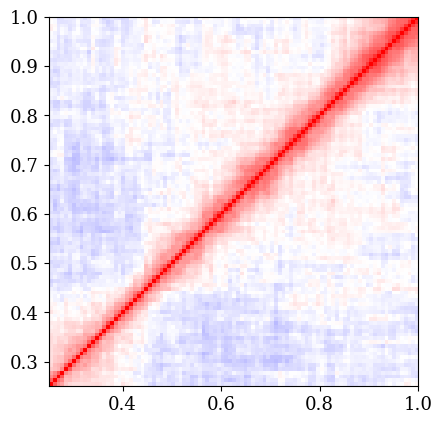

In [119]:
fm = fm_corrs[:, :, 2]
fig, axs = plt.subplots(1, 1)
axs.imshow(fm, origin='lower', vmin=-1, vmax=1,
          extent=[0.25, 1, 0.25, 1], cmap='bwr')
plt.show()

/var/folders/rs/w1_w_dfd5v3cjbx220100ydh0000gn/T/ipykernel_76470/2557211920.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('bwr', 10)                   # 10 discrete color bins


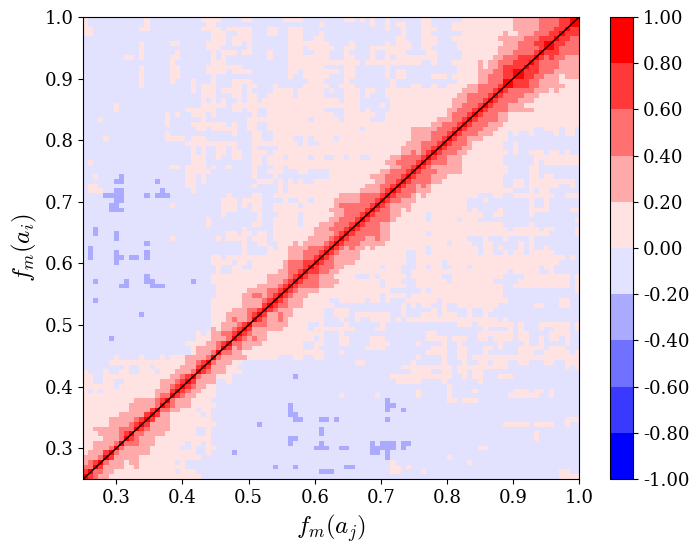

In [120]:
import matplotlib as mpl
fm = fm_corrs[:, :, 2]
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

cmap = mpl.cm.get_cmap('bwr', 10)                   # 10 discrete color bins
boundaries = np.linspace(-1.0, 1.0, 11)             # 10 bins -> 11 boundaries
norm = mpl.colors.BoundaryNorm(boundaries, cmap.N, clip=True)

# NOTE: do not pass vmin/vmax when passing a Normalize instance (BoundaryNorm)
im = ax.imshow(fm, origin='lower',
               extent=[0.25, 1, 0.25, 1],
               cmap=cmap, norm=norm,
               interpolation='nearest', aspect='auto')

# discrete colorbar with bin boundaries shown
cbar = fig.colorbar(im, ax=ax, boundaries=boundaries, ticks=boundaries)
cbar.ax.set_yticklabels([f"{b:.2f}" for b in boundaries])
plt.plot([0.25, 1], [0.25, 1], color='black', linestyle='-', linewidth=1)
plt.xlabel(r'$f_m(a_j)$')
plt.ylabel(r'$f_m(a_i)$')
plt.show()

/var/folders/rs/w1_w_dfd5v3cjbx220100ydh0000gn/T/ipykernel_76470/1425085486.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('bwr', 10)                   # 10 discrete color bins


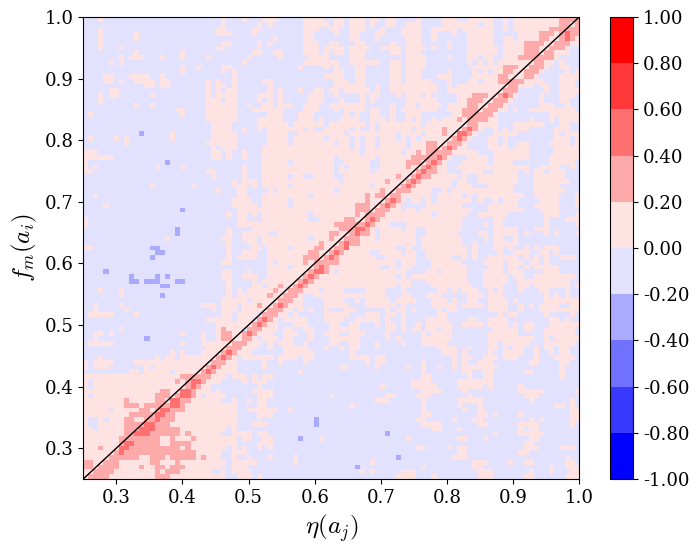

In [121]:
fm = fm_corrs[:, :, 0]
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

cmap = mpl.cm.get_cmap('bwr', 10)                   # 10 discrete color bins
boundaries = np.linspace(-1.0, 1.0, 11)             # 10 bins -> 11 boundaries
norm = mpl.colors.BoundaryNorm(boundaries, cmap.N, clip=True)

# NOTE: do not pass vmin/vmax when passing a Normalize instance (BoundaryNorm)
im = ax.imshow(fm, origin='lower',
               extent=[0.25, 1, 0.25, 1],
               cmap=cmap, norm=norm,
               interpolation='nearest', aspect='auto')

# discrete colorbar with bin boundaries shown
cbar = fig.colorbar(im, ax=ax, boundaries=boundaries, ticks=boundaries)
cbar.ax.set_yticklabels([f"{b:.2f}" for b in boundaries])
plt.plot([0.25, 1], [0.25, 1], color='black', linestyle='-', linewidth=1)
plt.xlabel(r'$\eta(a_j)$')
plt.ylabel(r'$f_m(a_i)$')
plt.show()

/var/folders/rs/w1_w_dfd5v3cjbx220100ydh0000gn/T/ipykernel_76470/632517488.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('bwr', 10)                   # 10 discrete color bins


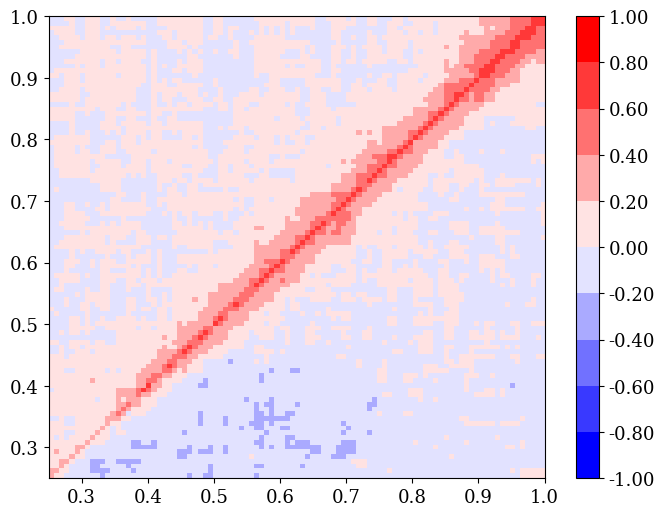

In [95]:
fm = fm_corrs[:, :, 1]
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

cmap = mpl.cm.get_cmap('bwr', 10)                   # 10 discrete color bins
boundaries = np.linspace(-1.0, 1.0, 11)             # 10 bins -> 11 boundaries
norm = mpl.colors.BoundaryNorm(boundaries, cmap.N, clip=True)

# NOTE: do not pass vmin/vmax when passing a Normalize instance (BoundaryNorm)
im = ax.imshow(fm, origin='lower',
               extent=[0.25, 1, 0.25, 1],
               cmap=cmap, norm=norm,
               interpolation='nearest', aspect='auto')

# discrete colorbar with bin boundaries shown
cbar = fig.colorbar(im, ax=ax, boundaries=boundaries, ticks=boundaries)
cbar.ax.set_yticklabels([f"{b:.2f}" for b in boundaries])

plt.show()

/var/folders/rs/w1_w_dfd5v3cjbx220100ydh0000gn/T/ipykernel_76470/2016442363.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('bwr', 10)                   # 10 discrete color bins


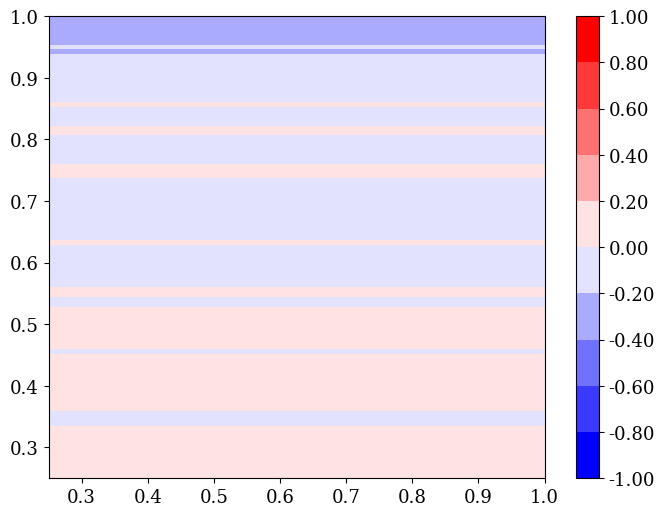

In [96]:
fm = fm_corrs[:, :, 3]
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

cmap = mpl.cm.get_cmap('bwr', 10)                   # 10 discrete color bins
boundaries = np.linspace(-1.0, 1.0, 11)             # 10 bins -> 11 boundaries
norm = mpl.colors.BoundaryNorm(boundaries, cmap.N, clip=True)

# NOTE: do not pass vmin/vmax when passing a Normalize instance (BoundaryNorm)
im = ax.imshow(fm, origin='lower',
               extent=[0.25, 1, 0.25, 1],
               cmap=cmap, norm=norm,
               interpolation='nearest', aspect='auto')

# discrete colorbar with bin boundaries shown
cbar = fig.colorbar(im, ax=ax, boundaries=boundaries, ticks=boundaries)
cbar.ax.set_yticklabels([f"{b:.2f}" for b in boundaries])

plt.show()

/var/folders/rs/w1_w_dfd5v3cjbx220100ydh0000gn/T/ipykernel_76470/1097522105.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('bwr', 10)                   # 10 discrete color bins


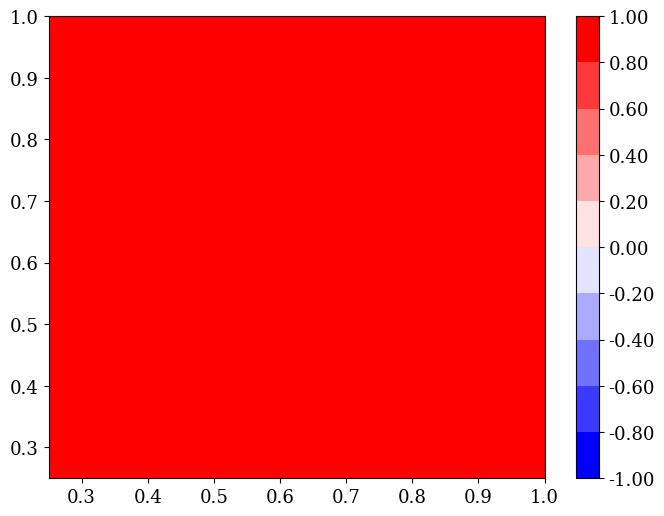

In [97]:
fm = fm_corrs[:, :, 4]
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

cmap = mpl.cm.get_cmap('bwr', 10)                   # 10 discrete color bins
boundaries = np.linspace(-1.0, 1.0, 11)             # 10 bins -> 11 boundaries
norm = mpl.colors.BoundaryNorm(boundaries, cmap.N, clip=True)

# NOTE: do not pass vmin/vmax when passing a Normalize instance (BoundaryNorm)
im = ax.imshow(fm, origin='lower',
               extent=[0.25, 1, 0.25, 1],
               cmap=cmap, norm=norm,
               interpolation='nearest', aspect='auto')

# discrete colorbar with bin boundaries shown
cbar = fig.colorbar(im, ax=ax, boundaries=boundaries, ticks=boundaries)
cbar.ax.set_yticklabels([f"{b:.2f}" for b in boundaries])

plt.show()

## Heatmaps of DS(a=1) on Roan and Elena's files

In [ ]:
rds_today = 'data/gadgetx3k_20/G3X_progenitors/DS_G3X_snap_128_center-cluster_progenitors.txt'
rds_today = pd.read_csv(rds_today, sep=r'\s+')
rds_today.drop(labels=['rID[0]', 'Hid[1]', 'DS_200[2]', 'DS_500[7]'],
               axis=1, inplace=True)
rds_today = rds_today[:20]

eds_today = 'data/gadgetx3k_20/snap_125.dyn'
eds_today = pd.read_csv(eds_today, sep=r'\s+', header=1)
eds_today.drop(labels=['region'], inplace=True, axis=1)

In [ ]:
rds_corr = rds_today.corr(method='spearman')
plots.plot_corr_matrix(rds_corr)

In [ ]:
eds_corr = eds_today.corr(method='spearman')
plots.plot_corr_matrix(eds_corr)

# MAH correlations

In [24]:
mah_df_dict = futils.get_mah_all('data/gadgetx3k/AHFHaloHistory/')
indxs = [k for k in mah_df_dict.keys()]
dsdf = futils.get_ds()
dsdf = dsdf.loc[indxs]

In [25]:
ma = np.array([df['M/M0'].values for _, df in mah_df_dict.items()])
scales = mah_df_dict[1]['aexp'].values
am, common_m = multicam.mah.get_am(ma, scales=scales, min_mass_bin=0.005)

/Users/kabelo/multicam/multicam/mah.py:153: RuntimeWarning: invalid value encountered in log
  interp1d(np.log(_m_peaks), np.log(_scales), bounds_error=False, fill_value=np.nan)


In [26]:
start = time.time()
ma_ds_dict, ma_corrs, filtered_z_list = corutils.build_ma_corrs(
    mah_df_dict, dsdf)
am_ds_dict, am_corrs = corutils.build_am_corrs(
    am, masses=common_m, df0=dsdf)
z_array = np.array(filtered_z_list)
aexp = 1/(1+z_array)
end = time.time()
print(f'{end-start:.1f}s')

11.6s


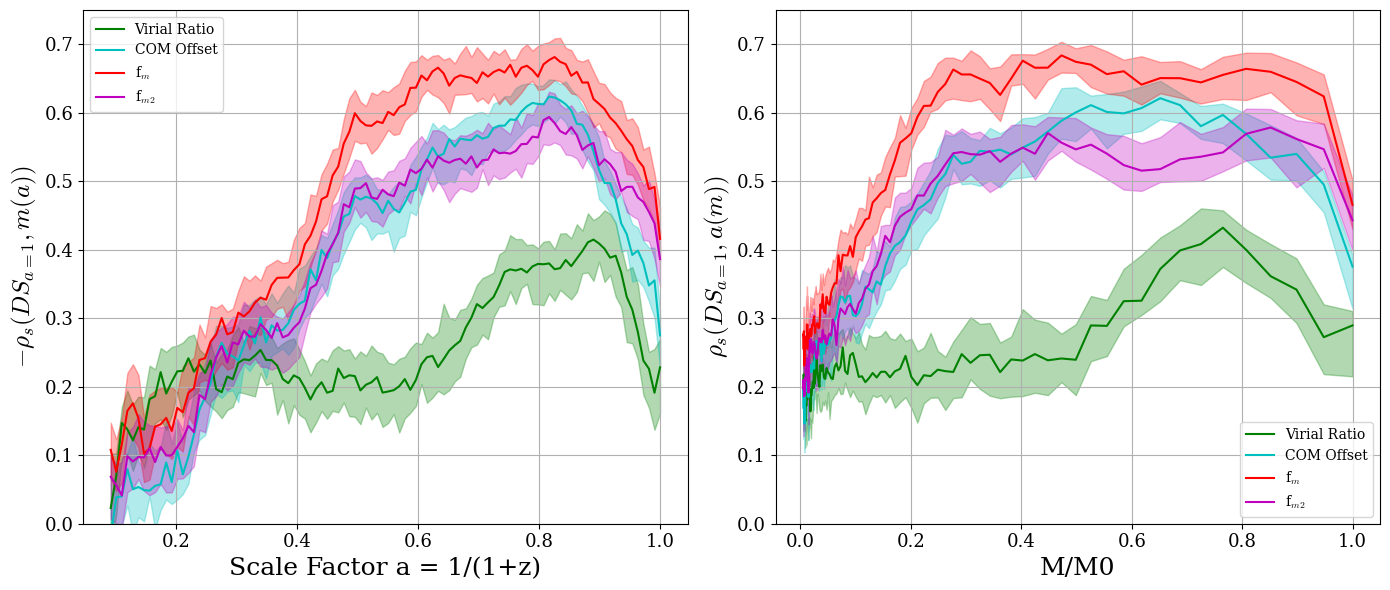

176.9s


In [39]:
start = time.time()
colors = ['g', 'c', 'r', 'm', 'b', 'y']
labels = ['Virial Ratio', 'COM Offset', r'f$_m$', r'f$_{m2}$']
yticks = np.arange(0., 0.8, 0.1)
ylim = (0, 0.75)
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for i, param in enumerate(dsdf.columns[:4]):

    p10, p25, p50, p75, p90 = datutils.get_percs(
        ma_ds_dict, param=param, history='M/M0')
    n10, n25, n50, n75, n90 = np.array(p10), np.array(p25), np.array(p50), np.array(p75), np.array(p90)
    # axs[0].set_title('m(a) correlations')
    axs[0].plot(aexp, -1*n50, color=colors[i], label=labels[i])
    # axs[0].fill_between(aexp, p10, p90, color=colors[i], alpha=0.2)
    axs[0].fill_between(aexp, -1*n25, -1*n75, color=colors[i], alpha=0.3)

    p10, p25, p50, p75, p90 = datutils.get_percs(
        am_ds_dict, param=param, history='am')
    # axs[1].set_title('a(m) correlations')
    axs[1].plot(common_m, p50, color=colors[i], label=labels[i])
    # axs[1].fill_between(common_m, p10, p90, color=colors[i], alpha=0.2)
    axs[1].fill_between(common_m, p25, p75, color=colors[i], alpha=0.3)

axs[0].set_xlabel('Scale Factor a = 1/(1+z)')
axs[0].set_ylabel(r'$-\rho_s (DS_{a=1}, m(a))$')
axs[0].set_yticks(yticks)
axs[0].set_ylim(ylim)
axs[0].grid()
axs[0].legend()

axs[1].set_xlabel('M/M0')
axs[1].set_ylabel(r'$\rho_s (DS_{a=1}, a(m))$')
axs[1].set_yticks(yticks)
axs[1].set_ylim(ylim)
axs[1].grid()
axs[1].legend()
plt.tight_layout()
plt.savefig('plots/ds_mah_corrs.pdf')
plt.show()

end = time.time()
print(f'{end-start:.1f}s')